In [11]:
pip install statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/60/15/3daba2df40be8b8a9a027d7f54c8dedf24f0d81b96e54b52293f5f7e3418/statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB 487.6 kB/s eta 0:00:20
   ---------------------------------------- 0.1/9.5 MB 653.6 kB/s eta 0:00:15
   - -------------------------------------- 0.3/9.5 MB 2.1 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/9.5 MB 2.7 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.5 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


In [2]:
weather_df = pd.read_csv("total_merged_data.csv")

In [10]:
weather_df.shape
columns_list = weather_df.columns.tolist() 
columns_list 

['time',
 'apparent_temperature_max_Amarillo, Texas',
 'apparent_temperature_max_Bloomington, Illinois',
 'apparent_temperature_max_Buenos Aires, Argentina',
 'apparent_temperature_max_Corrientes, Argentina',
 'apparent_temperature_max_Des Moines, Iowa',
 'apparent_temperature_max_Dhahran, Saudi Arabia',
 'apparent_temperature_max_Doha, Qatar',
 'apparent_temperature_max_Guaxupe, Brazil',
 'apparent_temperature_max_Houston, Texas',
 'apparent_temperature_max_Khon Kaen, Thailand',
 'apparent_temperature_max_Lake Wales, Florida',
 'apparent_temperature_max_Manizales, Colombia',
 'apparent_temperature_max_Muzaffarnagar, India',
 'apparent_temperature_max_Novy Urengoy, Russia',
 'apparent_temperature_max_Sorriso, Brazil',
 'apparent_temperature_max_Surgut, Russia',
 'apparent_temperature_max_São José do Rio Preto, Brazil',
 'apparent_temperature_max_São Paulo, Brazil',
 'apparent_temperature_max_Tongliao, China',
 'apparent_temperature_max_Toowoomba, Australia',
 'apparent_temperature_max_

In [14]:
weather_df 
df = weather_df 

Here we are looking at the pooled distributions of our varibales. Where pooled means flattened across all the locations 

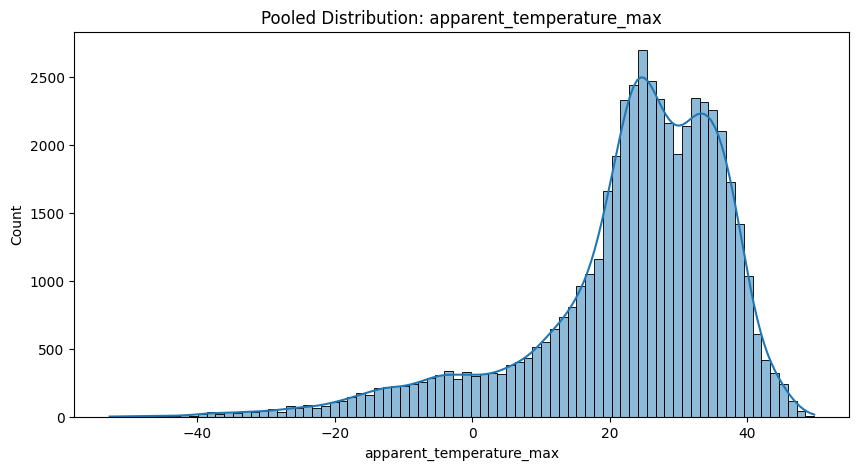

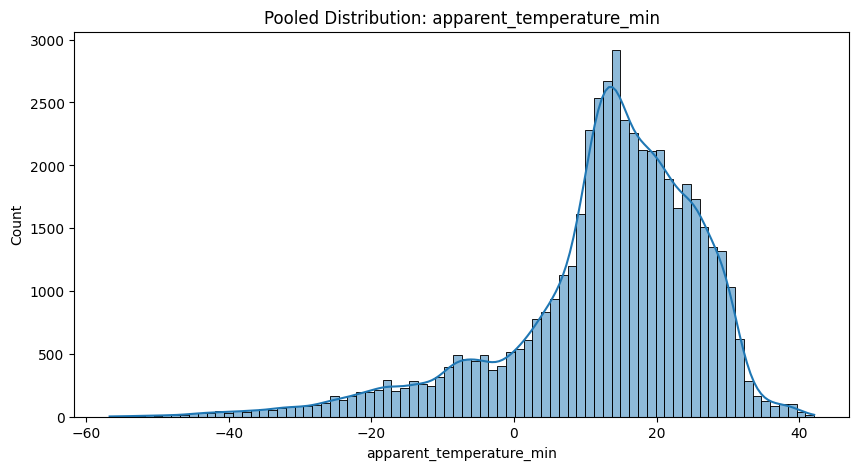

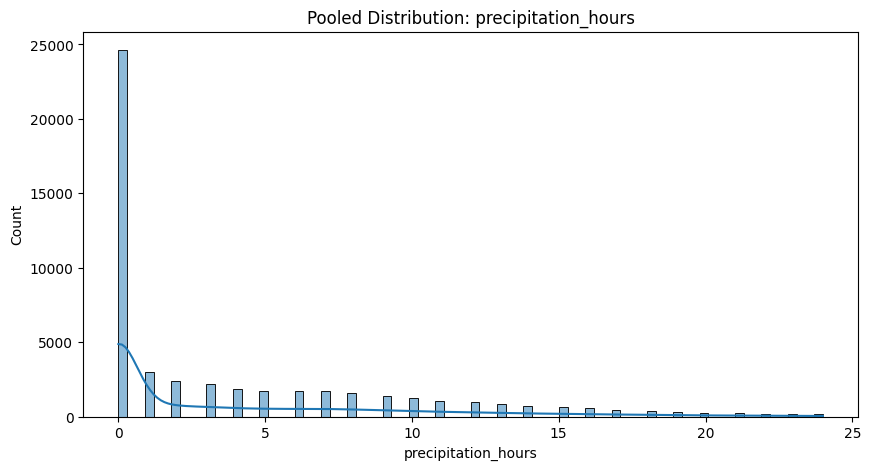

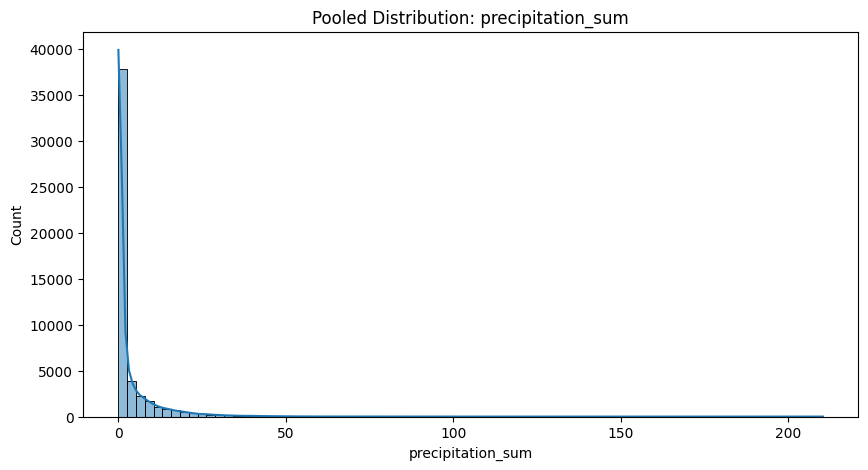

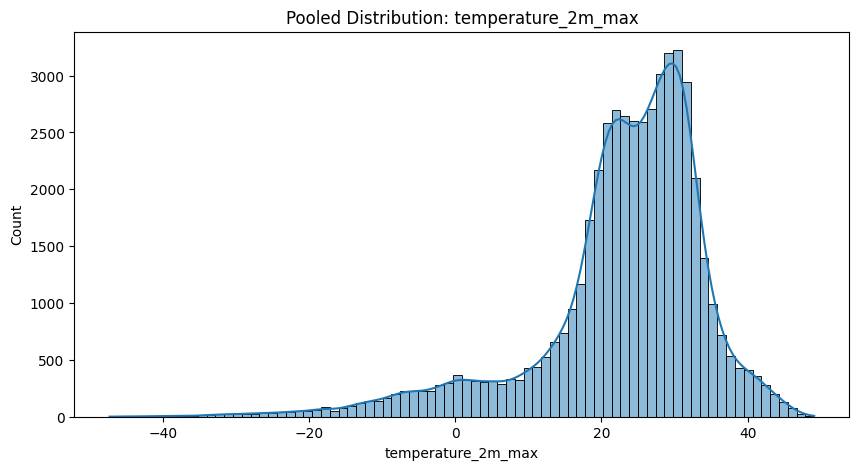

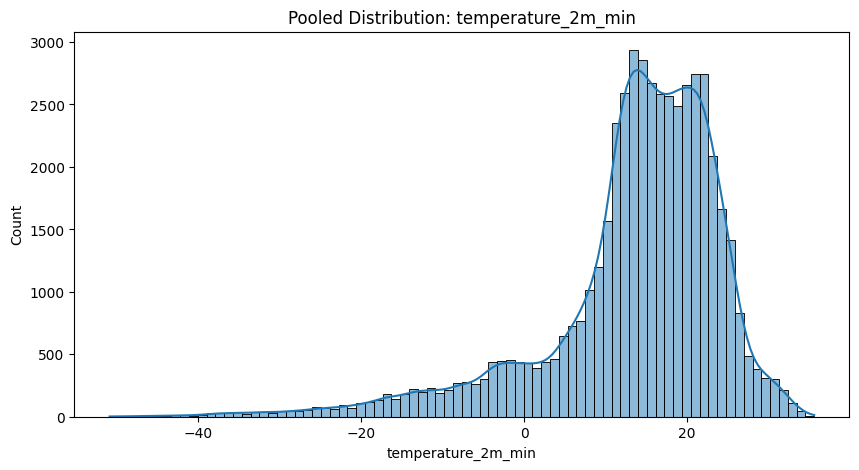

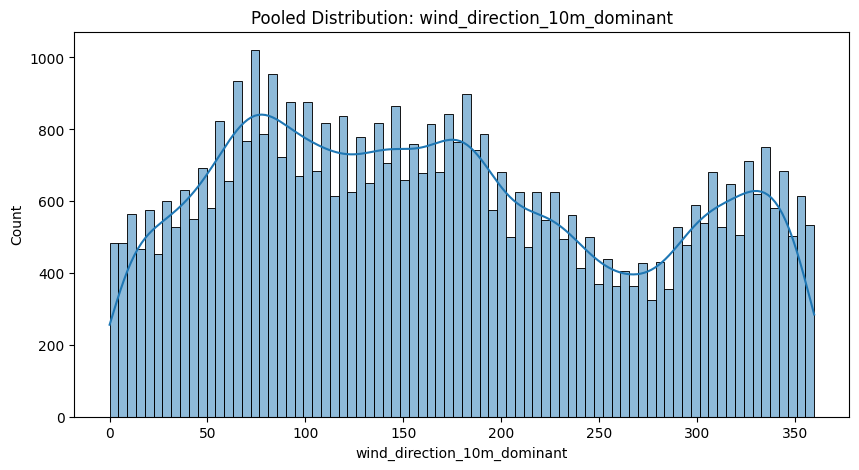

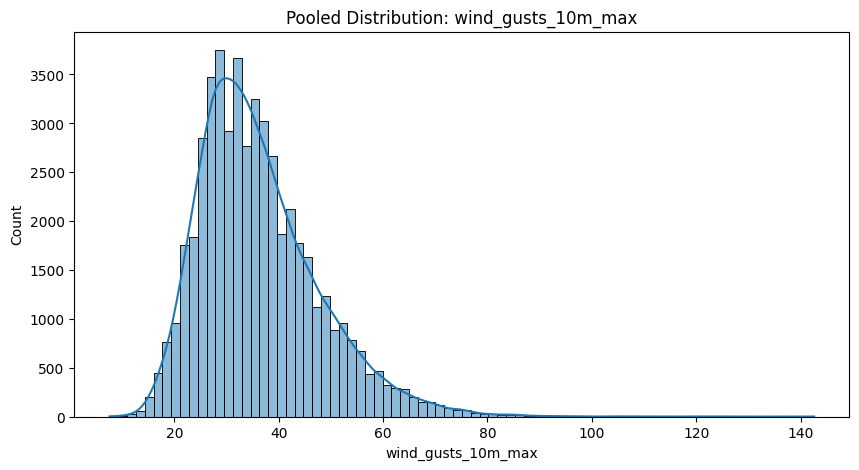

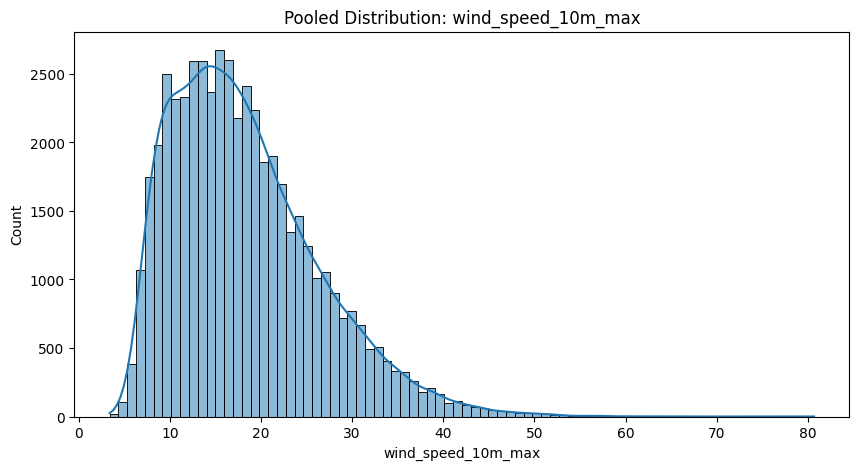

In [19]:
# Define the weather variable types
variable_types = [
    'apparent_temperature_max',
    'apparent_temperature_min',
    'precipitation_hours',
    'precipitation_sum',
    'temperature_2m_max',
    'temperature_2m_min',
    'wind_direction_10m_dominant',
    'wind_gusts_10m_max',
    'wind_speed_10m_max'
]

# Build a dict that pools all cities together for each variable
pooled = {}
for var in variable_types:
    cols = [c for c in df.columns if c.startswith(var + '_')]
    pooled[var] = df[cols].values.flatten()

# Example: look at the distribution of one variable
for  var in variable_types: 
    plt.figure(figsize=(10, 5))
    sns.histplot(pooled[var], bins=80, kde=True)
    plt.title(f'Pooled Distribution: {var}')
    plt.xlabel(var)

plt.show()

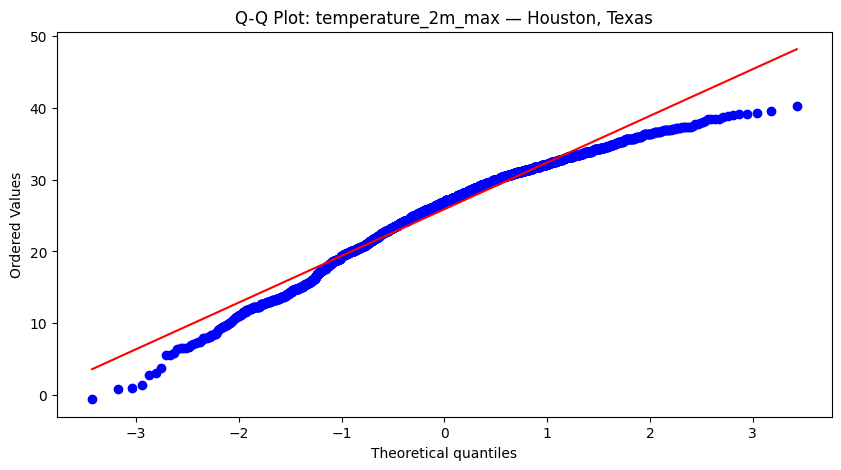

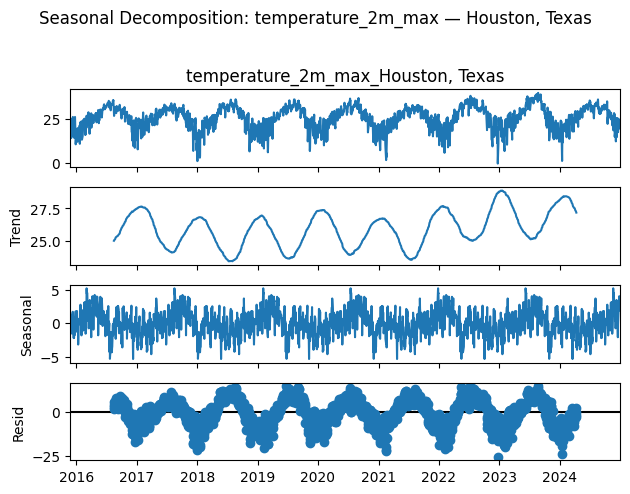

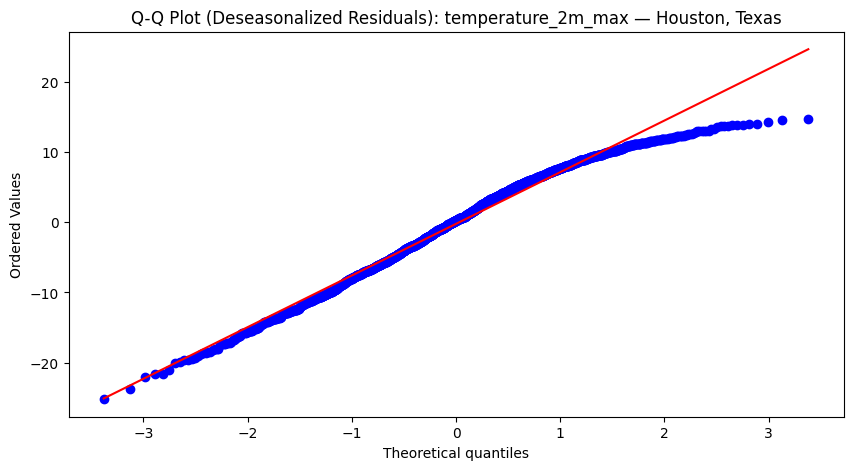

In [20]:
# 1. Single city Q-Q plot
city = 'Houston, Texas'
var = 'temperature_2m_max'
col = f'{var}_{city}'

plt.figure(figsize=(10, 5))
stats.probplot(df[col], plot=plt)
plt.title(f'Q-Q Plot: {var} — {city}')
plt.show()

# 2. Seasonal decomposition + residual Q-Q plot
series = df[col].copy()
series.index = pd.to_datetime(df['time'])

result = seasonal_decompose(series, model='additive', period=365)

# Plot the decomposition
result.plot()
plt.suptitle(f'Seasonal Decomposition: {var} — {city}', y=1.02)
plt.tight_layout()
plt.show()

# Q-Q plot on the residuals (drop NaNs from edges)
residuals = result.resid.dropna()

plt.figure(figsize=(10, 5))
stats.probplot(residuals, plot=plt)
plt.title(f'Q-Q Plot (Deseasonalized Residuals): {var} — {city}')
plt.show()